## Example 3b:
Calculating the Fisher information of different aberration coefficients as a function of defocus.
All from first principles, without any fitting or optical physics.
Meant to accompany Example 3a and provide a lower bound on the possible uncertainty of a coefficient estimate.

In [14]:
import math

import numpy as np
import torch
import pytorch_lightning as pl
from matplotlib import pyplot

In [15]:
from cynosure.config import NoiseConfig, OpticalConfig, PriorConfig, SimulationConfig, TrainingConfig, ZernikeConfig
from cynosure.information.fisher_information import calculate_fisher_matrix
from cynosure.utilities.visualization import plot_stack
from cynosure.zstack_decoding import (
    ZstackSolver_MixedDensity,
    make_object_distribution,
)

#### Simulation setup

In [16]:
# Simulation parameters:
pupil_grid_size = 255
object_grid_size = 31
object_pixel_size = 0.15  # um
rng_seed = 123

# Experimental parameters:
wavelength = 0.510  # um
focal_length = 4.50e3  # um
numerical_aperture = 0.9
medium_index = 1.54
immersion_index = 1.0
bead_diameter = 0.1  # um

# Fitting parameters:
max_phase_order = 6  # max Zernike N
max_amplitude_order = 4  # max Zernike N

device = "cuda" if torch.cuda.is_available() else "cpu"

In [17]:
z = torch.linspace(-1.5, 1.5, 7, device=device)

In [18]:
train_cfg = TrainingConfig(
    learning_rate=1e-3,
    weight_decay=1e-3,
    batch_size=32,
    generator_chunk=4,
    steps_per_epoch=200,
    val_batches=32,
    val_seed=42,
    mixing_warmup_epochs=10,
)
sim_cfg = SimulationConfig(
    pupil_grid_size=pupil_grid_size,
    object_grid_size=object_grid_size,
    object_pixel_size=object_pixel_size,
    ftype=torch.float32,
    ctype=torch.complex64,
)
opt_cfg = OpticalConfig(
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=numerical_aperture,
    aperture_type="fitted",
    medium_index=medium_index,
    immersion_index=immersion_index,
)
phase_cfg = ZernikeConfig(
    max_phase_order,
    allowed_nm=(
        (1, 1), (1, -1),
        (2, -2), (2, 0), (2, 2),
        (3, -3), (3, -1), (3, 1), (3, 3),
        (4, -4), (4, -2), (4, 0), (4, 2), (4, 4),
        (5, -5), (5, -3), (5, -1), (5, 1), (5, 3), (5, 5),
    )
)
amp_cfg = ZernikeConfig(
    max_amplitude_order,
    allowed_nm=(
        (0, 0), (2, 0), (4, 0)
    )
)
noise_cfg = NoiseConfig(
    min_photons=100_000,
    max_photons=1_000_000,
    max_background=1_000,
    read_noise=10,
)

In [19]:
object_distrib = make_object_distribution(sim_cfg.object_grid_size, sim_cfg.object_pixel_size, bead_diameter)
phase_prior = PriorConfig(0.05, 1)
amp_prior = PriorConfig(0.05, 2)

In [20]:
pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_MixedDensity(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    object_distribution=object_distrib,
    z_objective=z,
    num_components=1,
    noise_cfg=noise_cfg,
    hidden_channels=(8, 8),
    embedding_dims=32,
)
solver = solver.to(device)

Seed set to 123


#### Calculating and plotting the Fisher information matrix

In [21]:
num_samples = 64
phase_coefs, amp_coefs = solver.generate_phase_amp_coefficients(num_samples, device=solver.device)
coefs = solver.gather_nonpiston(solver.join_phase_amp(phase_coefs, amp_coefs))  # [B, C_kept]

fisher_matrix_samples = []
for coefs_i in coefs:  # TODO - figure out a way to vectorize this later
    _, fisher_matrix = calculate_fisher_matrix(coefs_i, z, solver)
    fisher_matrix_samples.append(fisher_matrix.numpy(force=True))
fisher_matrix_samples = np.concatenate(fisher_matrix_samples)
fisher_matrix_samples = fisher_matrix_samples.reshape(num_samples, z.shape[0], coefs.shape[-1], coefs.shape[-1])  # [num_samples, Z, C_kept, C_kept]

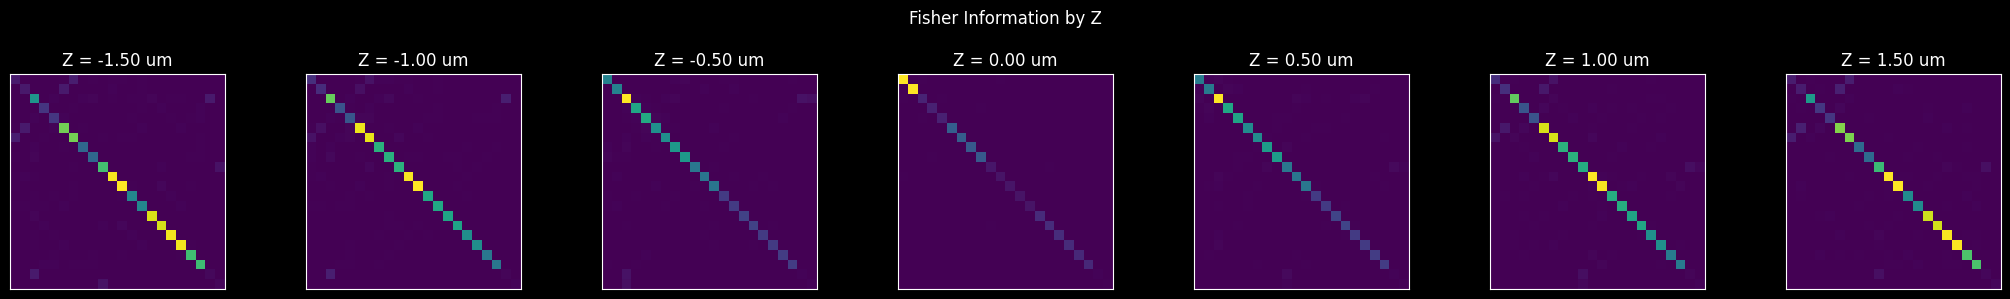

In [22]:
fig = plot_stack(fisher_matrix_samples.mean(0))  # misuse of `plot_stack`, but I won't tell anyone if you don't
for zval, ax in zip(z, fig.axes):
    ax.set_title(f"Z = {float(zval):.2f} um")
fig.suptitle("Fisher Information by Z")
fig.tight_layout()

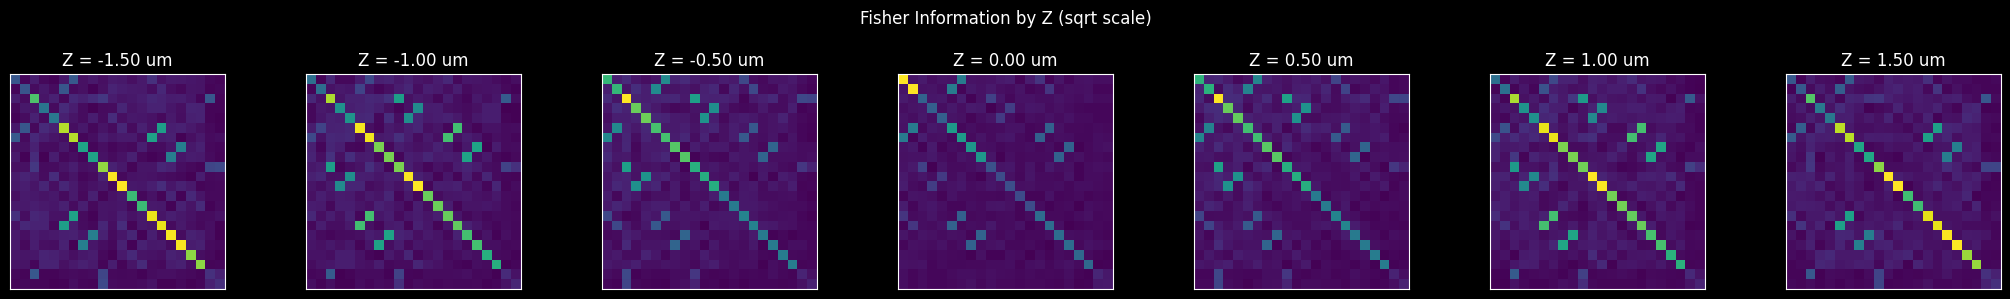

In [23]:
fig = plot_stack(np.sqrt(np.abs(fisher_matrix_samples.mean(0))))
for zval, ax in zip(z, fig.axes):
    ax.set_title(f"Z = {float(zval):.2f} um")
fig.suptitle("Fisher Information by Z (sqrt scale)")
fig.tight_layout()

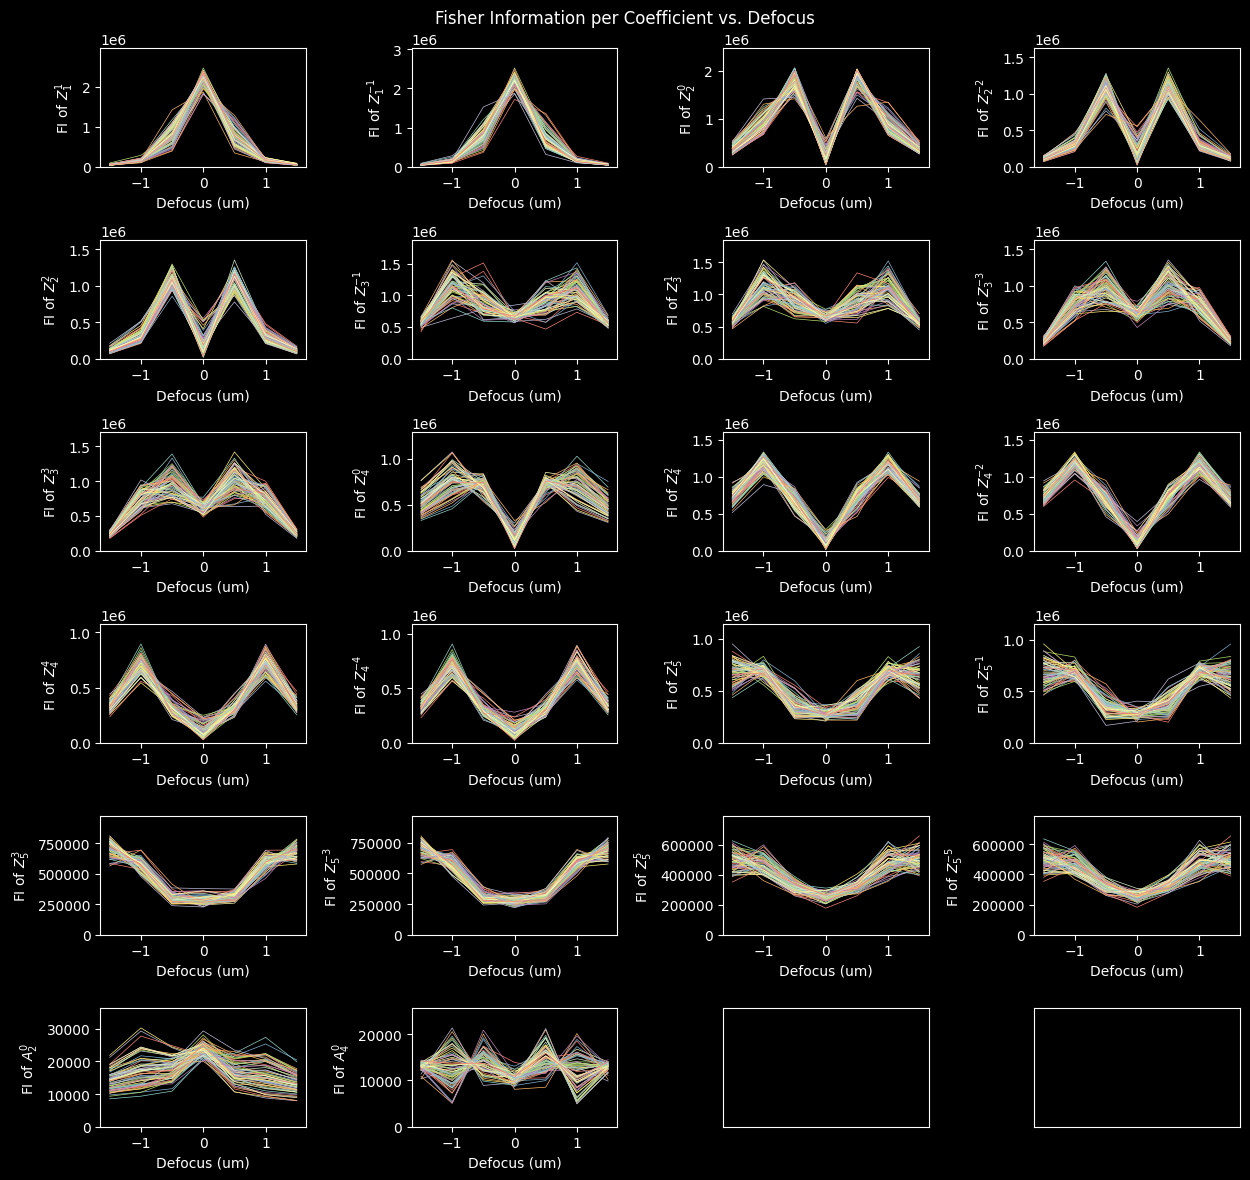

In [24]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.7

num_coefs = solver.num_nonpiston_coefs
num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)

labels = solver.nonpiston_labels

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        for bidx in range(num_samples):
            fi = fisher_matrix_samples[bidx, :, i, i]
            ax.plot(z.numpy(force=True), fi, lw=0.5)
            ax.set_ylabel(f"FI of {labels[i]}")
            ax.set_xlabel("Defocus (um)")
        max_val = np.abs(fisher_matrix_samples[:, :, i, i]).max()
        ax.set_ylim(0, max_val * 1.2)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.suptitle("Fisher Information per Coefficient vs. Defocus")
fig.tight_layout()

Cramer-Rao bounds the standard deviation of each measurement from below as 1/sqrt(Fisher).
I still need to make sure my Fisher information calculation is normalized correctly before I can compare these directly to the plots in Example 3a, but hopefully the trends, at least, will match up.

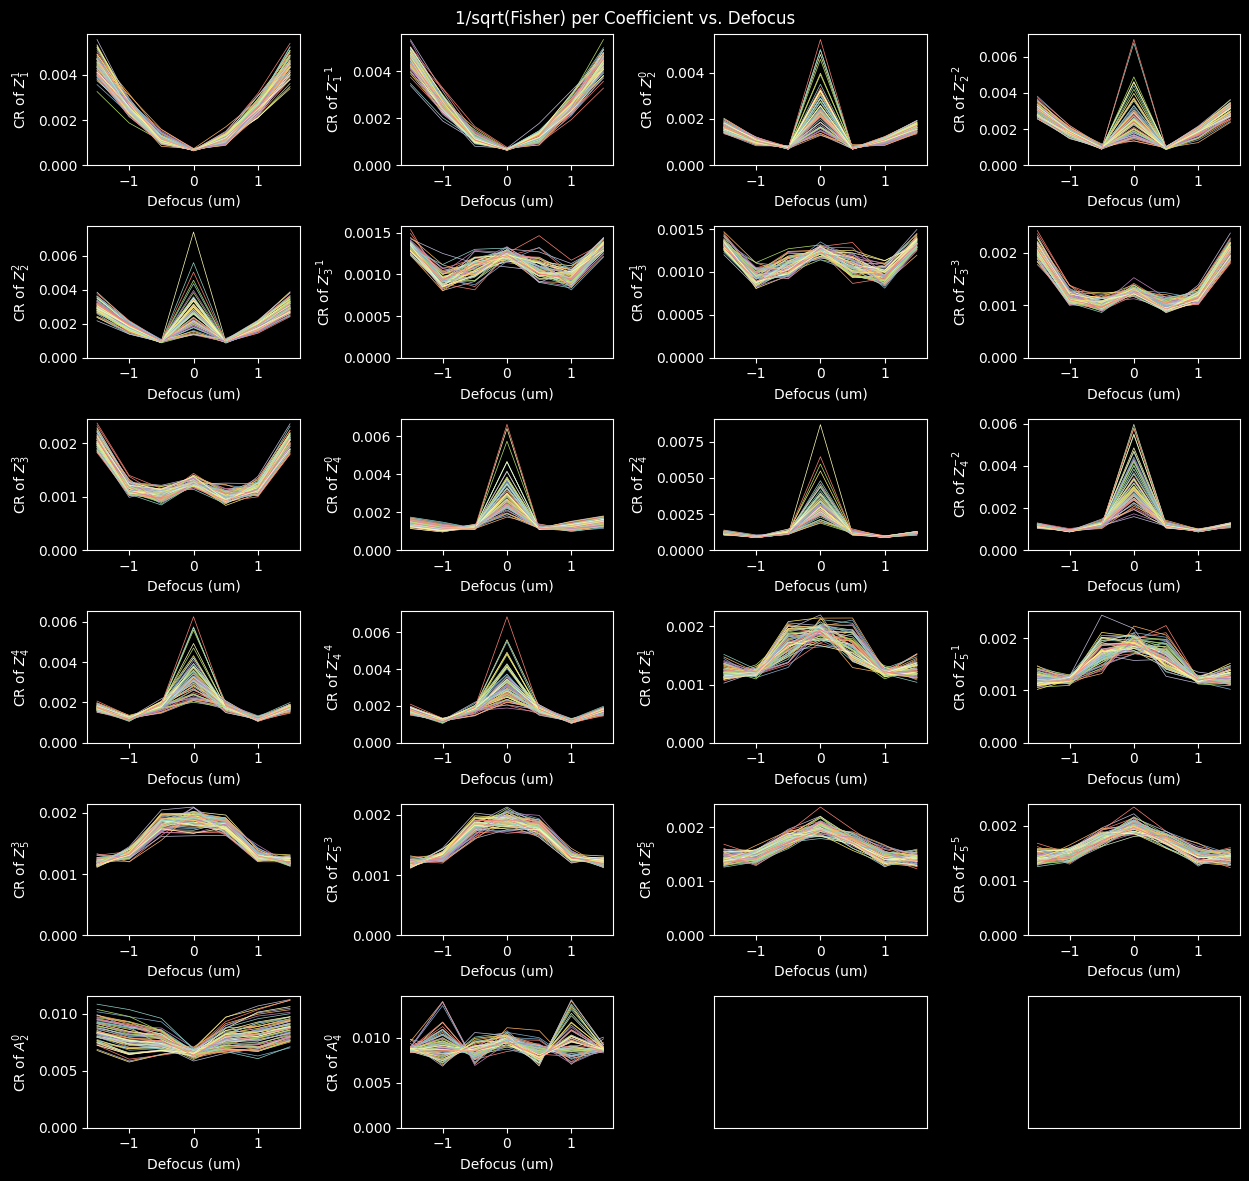

In [25]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.7

num_coefs = solver.num_nonpiston_coefs
num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)

labels = solver.nonpiston_labels

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        for bidx in range(num_samples):
            fi = fisher_matrix_samples[bidx, :, i, i]
            cr = 1.0 / np.sqrt(np.abs(fi))  # not really the Cramer-Rao bound, but proportional to
            ax.plot(z.numpy(force=True), cr, lw=0.5)
            ax.set_ylabel(f"CR of {labels[i]}")
            ax.set_xlabel("Defocus (um)")
        ax.set_ylim(bottom=0)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.suptitle("1/sqrt(Fisher) per Coefficient vs. Defocus")
fig.tight_layout()

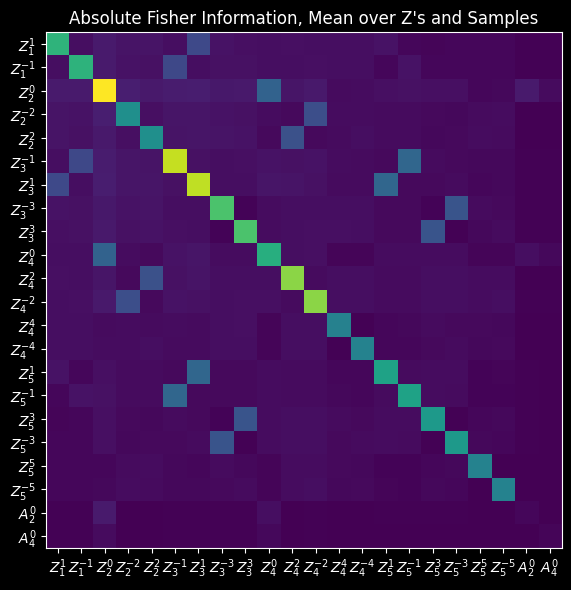

In [26]:
fig = pyplot.figure(figsize=(6, 6))
ax = fig.add_subplot()
ax.imshow(np.abs(fisher_matrix_samples).mean((0, 1)))

labels = solver.nonpiston_labels
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels)
ax.set_title("Absolute Fisher Information, Mean over Z's and Samples")
fig.tight_layout()